Library

In [2]:
# Library
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

Persiapan data

In [3]:
# Membaca data
data = pd.read_csv("Data F1 1950_2025.csv") 

# Filter variabel yang digunakan
df = data[(data['year'] >= 2014) & (data['year'] <= 2025)].copy()
df = df[['year','circuit','team']]

# Deskripsi Data
sirkuit_unik = df['circuit'].unique()
jumlah_sirkuit = len(sirkuit_unik)
print(f"Jumlah sirkuit unik: {jumlah_sirkuit}")
tim_unik = df['team'].unique()
jumlah_tim = len(tim_unik)
print(f"Jumlah tim unik: {jumlah_tim}")
print(f"Jumlah baris data: {len(df)}")

# Membuat pivot table
pivot_count = df.groupby(['circuit', 'team']).size().unstack(fill_value=0)

# Menghitung persentase kemenangan tim berdasarkan circuit
pivot_persen = pivot_count.div(pivot_count.sum(axis=1), axis=0)

#  Simpan di Excel
pivot_persen.to_excel('pivot_persen.xlsx')


Jumlah sirkuit unik: 32
Jumlah tim unik: 13
Jumlah baris data: 242


Menentukan jumlah kelompok dengan metode Elbow Method

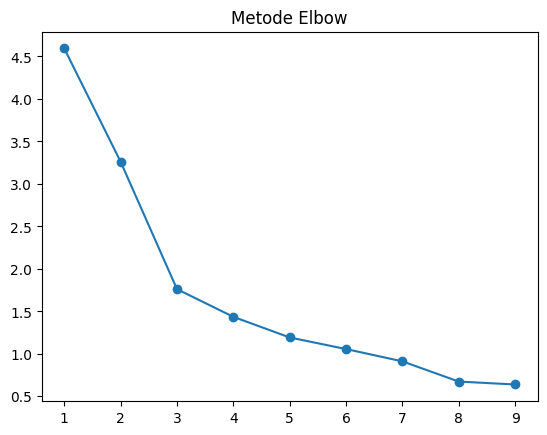

In [4]:
# Menentukan jumlah kelompok dengan metode Elbow

# Membuat plot Elbow
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=25)
    kmeans.fit(pivot_persen)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Metode Elbow')
plt.show()

Analisis cluster K-Means

In [6]:
# Analisis clustering K-Means
kmeans = KMeans(n_clusters=3, random_state=25)
pivot_persen['Cluster'] = kmeans.fit_predict(pivot_persen)

visualisasi PCA

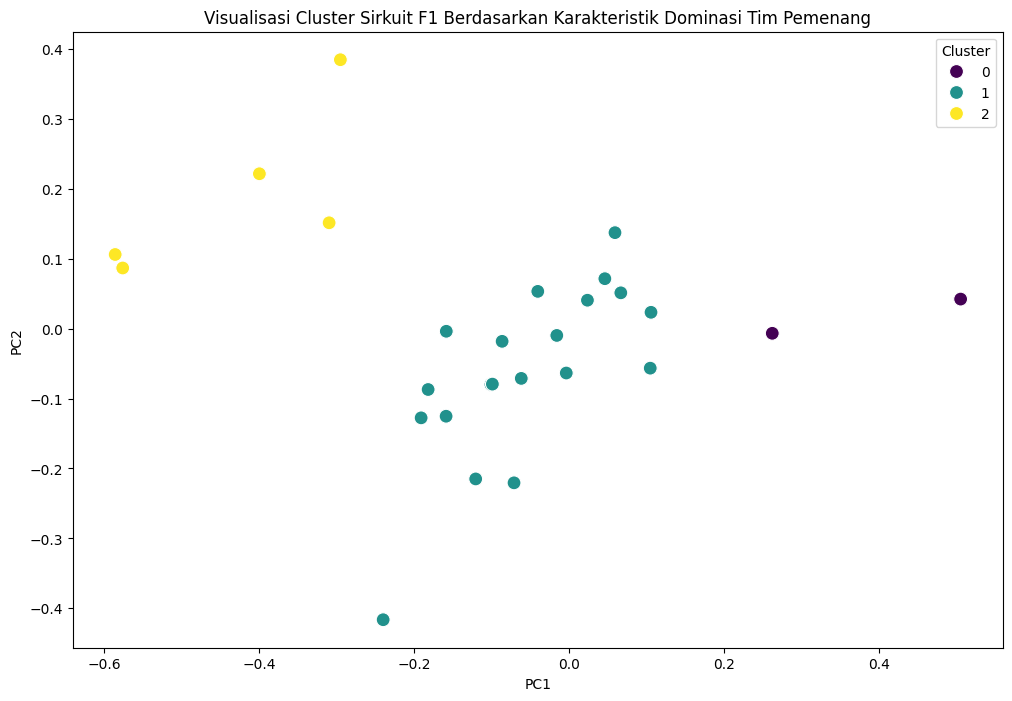

In [7]:
# Visualisasi dengan PCA 
pca = PCA(n_components=2)
pca_data = pca.fit_transform(pivot_persen.drop('Cluster', axis=1))
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = pivot_persen['Cluster'].values
pca_df['Circuit'] = pivot_persen.index

plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=100)

# # Menambahkan label nama sirkuit pada titik
# for i in range(pca_df.shape[0]):
#     plt.text(pca_df.PC1[i]+0.01, pca_df.PC2[i], pca_df.Circuit[i], fontsize=8, alpha=0.7)

plt.title('Visualisasi Cluster Sirkuit F1 Berdasarkan Karakteristik Dominasi Tim Pemenang')

# Ringkasan Karakteristik
# Melihat rata-rata kemenangan tiap tim di tiap cluster
cluster_summary = pivot_persen.groupby('Cluster').mean()
cluster_summary.to_excel('ringkasan_karakteristik_cluster.xlsx')
pivot_persen.to_excel('hasil_clustering.xlsx')
